# Spotify Data Analysis

This notebook explores a Spotify dataset to:
- analyze track features  
- identify popular songs  
- create a custom playlist based on audio characteristics  

## Data Loading and Overview

In [2]:
import pandas as pd

df = pd.read_csv("spotify_dataset.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Dataset Information

In [3]:
print(df.shape)      # rows, columns
df.info()            # data types
df.describe()        # stats

(114000, 21)
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Data Cleaning
Removing missing values to ensure clean analysis

In [4]:
df = df.dropna()   # remove missing values

## Most Popular Tracks

In [5]:
# Most popular songs
top = df.sort_values(by="popularity", ascending=False)
top[["track_name", "artists", "popularity"]].head(10)

,track_name,artists,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
89411,La Bachata,Manuel Turizo,98
81210,I'm Good (Blue),David Guetta;Bebe Rexha,98
68303,La Bachata,Manuel Turizo,98
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98
88410,La Bachata,Manuel Turizo,98
30003,I'm Good (Blue),David Guetta;Bebe Rexha,98
67356,La Bachata,Manuel Turizo,98


## Playlist Generation (High Energy + Danceability)

Filtering songs based on:
- high energy (> 0.7)  
- high danceability (> 0.7)  

In [6]:
# Example: High energy + danceable songs
playlist = df[(df["energy"] > 0.7) & (df["danceability"] > 0.7)]

playlist[["track_name", "artists", "energy", "danceability"]].head()

,track_name,artists,energy,danceability
14,Hold On - Remix,Chord Overstreet;Deepend,0.780,0.755
76,Kaleidoscope,A Great Big World,0.913,0.709
365,アジアの純真,Yosui Inoue;Tamio Okuda,0.830,0.732
584,All My Loving (Original Version),Masaharu Fukuyama,0.746,0.725
593,Outside Villanova,Eric Hutchinson,0.732,0.785


In [7]:
top_songs = df.sort_values(by="popularity", ascending=False)

top_songs[["track_name", "artists", "popularity"]].head(10)

,track_name,artists,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
89411,La Bachata,Manuel Turizo,98
81210,I'm Good (Blue),David Guetta;Bebe Rexha,98
68303,La Bachata,Manuel Turizo,98
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98
88410,La Bachata,Manuel Turizo,98
30003,I'm Good (Blue),David Guetta;Bebe Rexha,98
67356,La Bachata,Manuel Turizo,98


In [8]:
playlist.to_csv("my_playlist.csv", index=False) # Exporting Playlist

In [9]:
# Low energy chill songs
chill = df[(df["energy"] < 0.4)]

# Most danceable song
print(df.loc[df["danceability"].idxmax()])

Unnamed: 0                          111635
track_id            4xKKIS9g9nivSiE7TtgR6V
artists                            Quantic
album_name             The Best of Quantic
track_name                        Sol Clap
popularity                              19
duration_ms                         232853
explicit                             False
danceability                         0.985
energy                               0.651
key                                      9
loudness                             -5.62
mode                                     0
speechiness                          0.217
acousticness                       0.00121
instrumentalness                     0.176
liveness                             0.064
valence                              0.405
tempo                              115.347
time_signature                           4
track_genre                       trip-hop
Name: 111635, dtype: object


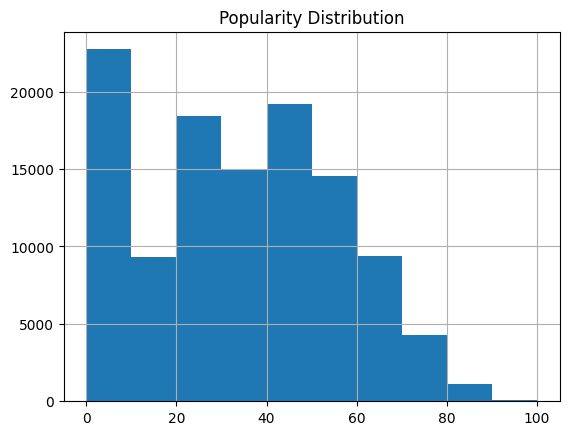

In [10]:
import matplotlib.pyplot as plt

df["popularity"].hist()
plt.title("Popularity Distribution")
plt.show()

## Conclusion

- High energy and danceability features help identify party tracks  
- Popular songs are not always the most danceable  
- Feature-based filtering allows creation of personalized playlists  
- Dataset size enables scalable analysis  

This approach can be extended to:
- mood-based playlists  
- genre-specific filtering  
- recommendation systems  